# Importing libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels as sm

# Time-series econometrics
from statsmodels.tsa.api import VAR

# Preparing the data

In [2]:
df = pd.read_csv(r"../data/processed/weekly_cleaned_data.csv", index_col="Dates", parse_dates=True)
print(df.sample(4))

             ret_wti  er_sp500  d_spread_hy    rv_wti  rv_sp500     rv_hy
Dates                                                                    
1998-12-04 -0.029955 -0.014018     0.000970  0.004054  0.001558  0.000003
2021-08-20 -0.093201 -0.005954     0.000330  0.001878  0.000241  0.000001
2003-08-15 -0.034256  0.012946     0.000798  0.001153  0.000192  0.000053
2001-04-27  0.024710  0.007250     0.000170  0.002752  0.000872  0.000003


## Testing for Stationarity

In [3]:
variables = df.columns.tolist()
for i in variables:
    result = sm.tsa.stattools.adfuller(df[i])
    print(f"{i}: ADF = {result[0]:.4f}, nb of lags used {result[2]}, p-value = {result[1]:.6f}")

ret_wti: ADF = -11.8303, nb of lags used 8, p-value = 0.000000
er_sp500: ADF = -20.5501, nb of lags used 3, p-value = 0.000000
d_spread_hy: ADF = -7.9360, nb of lags used 22, p-value = 0.000000
rv_wti: ADF = -7.4003, nb of lags used 10, p-value = 0.000000
rv_sp500: ADF = -8.5132, nb of lags used 6, p-value = 0.000000
rv_hy: ADF = -6.3951, nb of lags used 11, p-value = 0.000000


## Number of lags selection

In [4]:
# VAR 1 lag selection (returns)
var1_data = df[["ret_wti", "er_sp500", "d_spread_hy"]]
model1 = VAR(var1_data)
results1 = model1.select_order(maxlags=20)
print(results1.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -25.49      -25.48   8.527e-12      -25.48
1       -25.64     -25.59*   7.330e-12      -25.62
2       -25.66      -25.58   7.198e-12     -25.63*
3       -25.66      -25.55   7.197e-12      -25.62
4       -25.66      -25.52   7.149e-12      -25.61
5       -25.67      -25.49   7.103e-12      -25.60
6       -25.67      -25.46   7.108e-12      -25.59
7       -25.68      -25.43   7.064e-12      -25.58
8       -25.68      -25.40   7.032e-12      -25.58
9       -25.68      -25.37   7.030e-12      -25.56
10      -25.68      -25.33   7.058e-12      -25.55
11     -25.68*      -25.30  7.020e-12*      -25.54
12      -25.68      -25.27   7.062e-12      -25.52
13      -25.67      -25.23   7.073e-12      -25.51
14      -25.67      -25.20   7.086e-12      -25.49
15      -25.67      -25.16   7.134e-12      -25.48
16      -25.66      -25.11   7.

/Users/rijadtalovic/miniconda3/envs/emif/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


interpretation de des resultats de la selection 2

In [5]:
# VAR 2 lag selection (realized variances)
var2_data = df[["rv_wti", "rv_sp500", "rv_hy"]]
model2 = VAR(var2_data)
results2 = model2.select_order(maxlags=20)
print(results2.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -48.79      -48.78   6.437e-22      -48.79
1       -49.78      -49.74   2.404e-22      -49.76
2       -49.89     -49.81*   2.152e-22      -49.86
3       -49.91      -49.79   2.120e-22      -49.86
4       -49.92      -49.78   2.085e-22     -49.87*
5       -49.92      -49.74   2.088e-22      -49.85
6       -49.92      -49.71   2.085e-22      -49.84
7       -49.93      -49.68   2.072e-22      -49.84
8       -49.93      -49.65   2.075e-22      -49.82
9       -49.92      -49.61   2.082e-22      -49.81
10      -49.93      -49.58   2.077e-22      -49.80
11      -49.93      -49.55   2.075e-22      -49.79
12      -49.93      -49.52   2.065e-22      -49.78
13     -49.93*      -49.49  2.060e-22*      -49.77
14      -49.93      -49.45   2.070e-22      -49.75
15      -49.93      -49.42   2.071e-22      -49.74
16      -49.92      -49.38   2.

/Users/rijadtalovic/miniconda3/envs/emif/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


interpretation de des resultats de la selection 2

## Model Var 1

In [6]:
var1_fitted = model1.fit(2)
print(var1_fitted.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 27, Mar, 2026
Time:                     18:34:23
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -25.5605
Nobs:                     1438.00    HQIC:                  -25.6087
Log likelihood:           12333.1    FPE:                7.34145e-12
AIC:                     -25.6375    Det(Omega_mle):     7.23527e-12
--------------------------------------------------------------------
Results for equation ret_wti
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  0.001519         0.001356            1.120           0.263
L1.ret_wti            -0.003263         0.027648           -0.118           0.906
L1.er_sp500           -0.138745         0.071476      

Here, we have a lot to interpret and nuance :

- **L1.d_spread_hy → ret_wti (p=0.000, coeff=-2.66)** : the strongest result of VAR 1 : a widening of HY spreads last week predicts a decline in WTI this week. This is an interesting reverse channel : while our research question focuses on oil shocks transmitting to financial markets, this result suggests a feedback loop where credit market stress feeds back into oil prices, consistent with a global risk-off dynamic where deteriorating credit conditions signal weakening economic demand and thus lower oil prices.

- **L2.ret_wti → ret_wti (p=0.004, coeff=-0.081)** : mild mean-reversion of WTI at 2 weeks : a large move tends to partially correct itself.

- **L1.er_sp500 → er_sp500 (p=0.003, coeff=-0.104)** : mild mean-reversion of SP500 at 1 week. This could seem to contradict the EMH, however it is economically negligible after transaction costs and is a well-documented short-term institutional rebalancing effect (mean-reversal phenomena).

- **L1.er_sp500 → d_spread_hy (p=0.008)** : SP500 leads HY in the returns channel :meaning that in terms of price direction, equity markets appear to move before credit markets, which is consistent with the illiquidity and slow price discovery of the HY market discussed earlier.

- **Residual correlation er_sp500 / d_spread_hy = -0.645** : the dominant relationship between SP500 and HY is contemporaneous — when SP500 rises, HY spreads compress instantly within the same week. This fully justifies the Cholesky decomposition to capture this instantaneous channel.

All remaining coefficients are not significant, broadly confirming the EMH past returns of WTI, SP500 and HY carry little predictive power over each other. The dominant dynamics between these markets operate contemporaneously rather than with a lag, which motivates our VAR 2 analysis to uncover the persistent risk transmission channel through realized variances.

In [7]:
var2_fitted = model2.fit(4)
print(var2_fitted.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 27, Mar, 2026
Time:                     18:34:23
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -49.7474
Nobs:                     1436.00    HQIC:                  -49.8371
Log likelihood:           29747.6    FPE:                2.15185e-22
AIC:                     -49.8905    Det(Omega_mle):     2.09445e-22
--------------------------------------------------------------------
Results for equation rv_wti
                 coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------
const               0.000610         0.000097            6.298           0.000
L1.rv_wti           0.270146         0.027358            9.875           0.000
L1.rv_sp500         0.348925         0.104309            3.345     

## Granger Causality Tests

In [8]:
def granger_table(fitted, pairs):
    rows = []
    for causing, caused in pairs:
        res = fitted.test_causality(caused=caused, causing=causing)
        rows.append({
            "Causing variable": causing,
            "Caused variable": caused,
            "Test statistic": round(res.test_statistic, 4),
            "p-value": round(res.pvalue, 4),
            "Significant at 5%": "Yes" if res.pvalue < 0.05 else "No",
        })
    return pd.DataFrame(rows)

pairs_var1 = [
    ("ret_wti", "er_sp500"),
    ("ret_wti", "d_spread_hy"),
    ("er_sp500", "ret_wti"),
    ("er_sp500", "d_spread_hy"),
    ("d_spread_hy", "ret_wti"),
    ("d_spread_hy", "er_sp500"),
]

pairs_var2 = [
    ("rv_wti", "rv_sp500"),
    ("rv_wti", "rv_hy"),
    ("rv_sp500", "rv_wti"),
    ("rv_sp500", "rv_hy"),
    ("rv_hy", "rv_wti"),
    ("rv_hy", "rv_sp500"),
]

print("Granger Causality: VAR 1 (returns)")
display(granger_table(var1_fitted, pairs_var1))

print("\nGranger Causality: VAR 2 (realized variances)")
display(granger_table(var2_fitted, pairs_var2))

Granger Causality: VAR 1 (returns)


,Causing variable,Caused variable,Test statistic,p-value,Significant at 5%
0,ret_wti,er_sp500,1.3625,0.2561,No
1,ret_wti,d_spread_hy,1.7520,0.1735,No
2,er_sp500,ret_wti,1.9653,0.1402,No
3,er_sp500,d_spread_hy,4.1346,0.0161,Yes
4,d_spread_hy,ret_wti,11.5768,0.0000,Yes
5,d_spread_hy,er_sp500,0.9272,0.3957,No



Granger Causality: VAR 2 (realized variances)


,Causing variable,Caused variable,Test statistic,p-value,Significant at 5%
0,rv_wti,rv_sp500,2.2974,0.0567,No
1,rv_wti,rv_hy,7.8036,0.0000,Yes
2,rv_sp500,rv_wti,5.7388,0.0001,Yes
3,rv_sp500,rv_hy,12.0214,0.0000,Yes
4,rv_hy,rv_wti,7.0133,0.0000,Yes
5,rv_hy,rv_sp500,5.4570,0.0002,Yes


**Granger Causality Tests — Interpretation :**

**VAR 1 (returns) :** Only two significant relationships : d_spread_hy → ret_wti 
and er_sp500 → d_spread_hy. The latter likely reflects a difference in adjustment 
speed rather than true causality : both markets react to the same information but 
the liquid equity market adjusts instantly while the illiquid HY market takes an 
additional week, consistent with our ACF findings. All other relationships confirm 
the EMH.

**VAR 2 (realized variances) :** The key result is the indirect transmission chain 
WTI → HY → SP500 : oil volatility Granger-causes HY (p=0.000), HY Granger-causes 
SP500 (p=0.0002), but WTI does not directly cause SP500 (p=0.057). This confirms 
our central hypothesis — oil shocks reach equity markets through the credit channel, 
with HY acting as a mediator and early warning signal.

The Granger causality results reveal a clear transmission structure in the variance 
channel. While all three variables are broadly interconnected, the critical finding 
is that WTI does not directly Granger-cause SP500 (p=0.057) but does cause HY 
(p=0.000), which in turn causes SP500 (p=0.0002). This indirect chain 
WTI → HY → SP500 is the only unidirectional path in the system and is precisely 
consistent with our economic intuition : oil volatility first contaminates credit 
markets, which then act as a transmission belt to equity markets.

This result also informs our Cholesky ordering for the IRF analysis : placing WTI 
first, HY second and SP500 last is not only economically justified but now 
empirically supported by the Granger tests.

However, it is important to note that Granger causality captures relationships 
between past levels of variance — it tells us that elevated HY volatility last week 
predicts elevated SP500 volatility this week, but it does not tell us how the system 
responds to a sudden unexpected shock. This is precisely what the Impulse Response 
Functions will address next : by orthogonalizing the shocks via Cholesky 
decomposition, we can trace the dynamic response of HY and SP500 to a one standard 
deviation shock on WTI volatility, and assess both the magnitude and persistence of 
this transmission.

## Impulse Response Functions

## !!!!! pas oublier de remplacxer l output 13x3x3!!!!

/Users/rijadtalovic/miniconda3/envs/emif/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/Users/rijadtalovic/miniconda3/envs/emif/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


VAR 1 — impulse vector (ret_wti shock): [ 0.05128408 -0.00084161  0.00623583]
VAR 2 — impulse vector (rv_wti shock):  [2.52727627e-03 1.98358656e-06 1.57063833e-04]


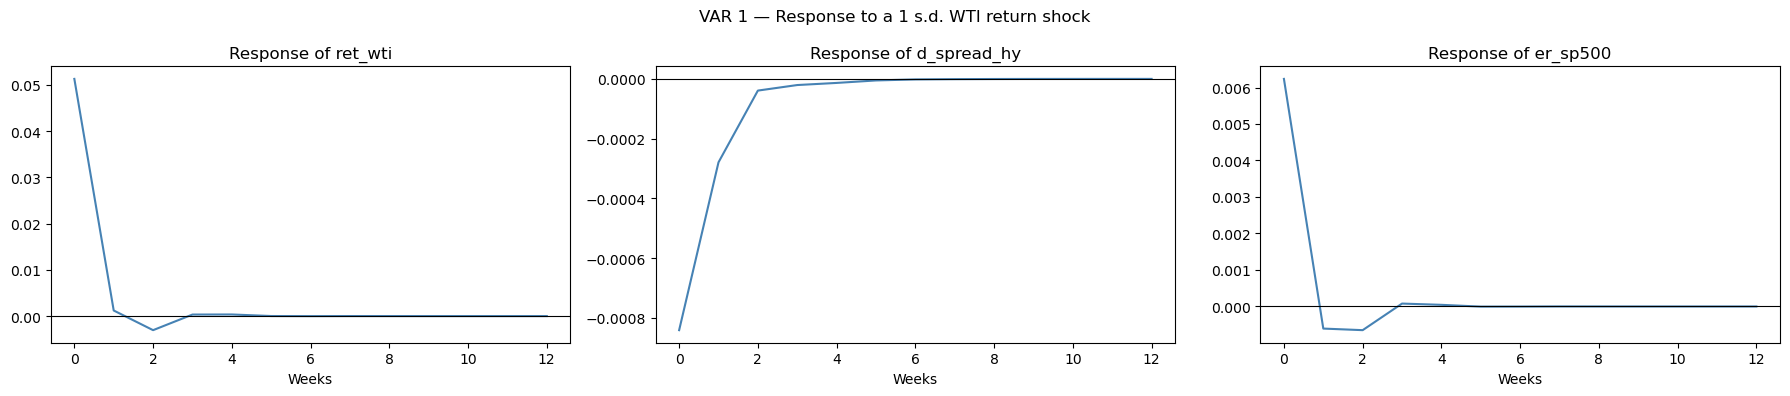

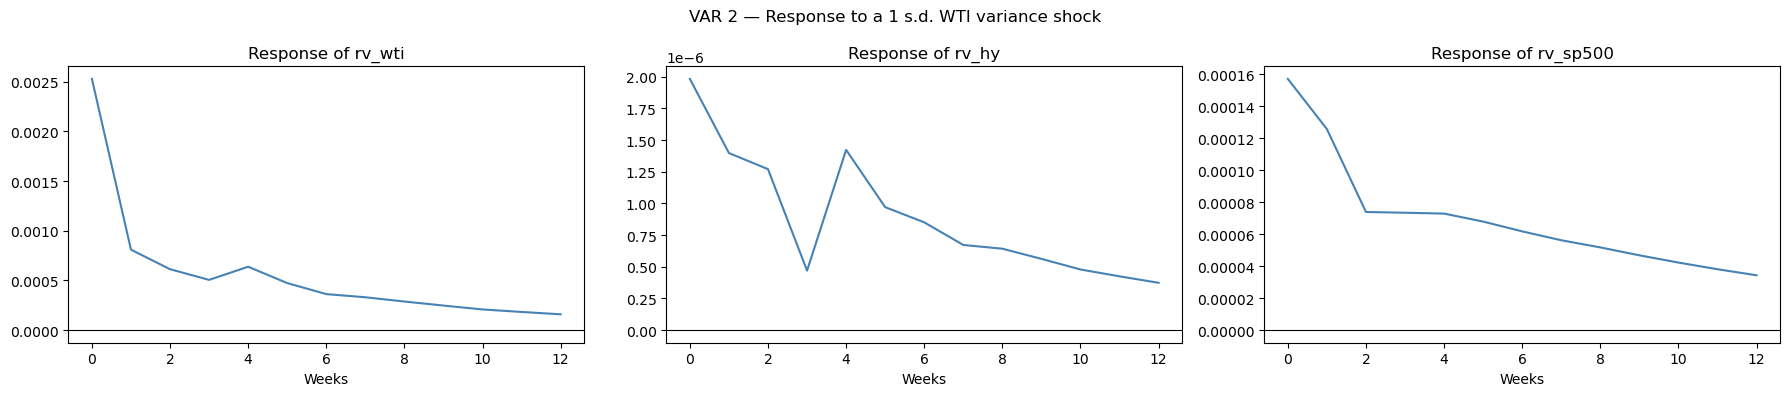

In [ ]:
# Cholesky ordering: WTI first, HY second, SP500 last
variables_var1 = ["ret_wti", "d_spread_hy", "er_sp500"]
variables_var2 = ["rv_wti",  "rv_hy",       "rv_sp500"]

irf_var1_fitted = VAR(df[variables_var1]).fit(2)
irf_var2_fitted = VAR(df[variables_var2]).fit(4)

# VAR 1 — impulse vector for the WTI shock
P1             = np.linalg.cholesky(irf_var1_fitted.sigma_u)
shock_vector   = np.array([1, 0, 0])   # shock on ret_wti only
impulse_vector1 = P1 @ shock_vector
print(f"VAR 1 — impulse vector (ret_wti shock): {impulse_vector1}")

# VAR 2 — impulse vector for the WTI variance shock
P2             = np.linalg.cholesky(irf_var2_fitted.sigma_u)
impulse_vector2 = P2 @ shock_vector
print(f"VAR 2 — impulse vector (rv_wti shock):  {impulse_vector2}")

def compute_orth_irf(lag_matrices, cholesky_P, n_periods):
    n_lags = len(lag_matrices)
    n_vars = lag_matrices.shape[1]

    responses = np.zeros((n_periods + 1, n_vars, n_vars))
    responses[0] = np.eye(n_vars)  # period 0: identity (no dynamics yet)

    for period in range(1, n_periods + 1):
        # at each week, sum contributions from all previous periods weighted by VAR lag matrices
        for lag in range(1, min(period, n_lags) + 1):
            responses[period] += lag_matrices[lag-1] @ responses[period - lag]

    return np.array([responses[s] @ cholesky_P for s in range(n_periods + 1)])

# roll the shock through 12 weeks
manual1 = compute_orth_irf(irf_var1_fitted.coefs, P1, 12)
manual2 = compute_orth_irf(irf_var2_fitted.coefs, P2, 12)

# ---- VAR 1 ----
imp1 = variables_var1.index("ret_wti")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, resp, title in zip(axes, range(3), variables_var1):
    ax.plot(manual1[:, resp, imp1], color="steelblue")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"Response of {title}")
    ax.set_xlabel("Weeks")
fig.suptitle("VAR 1 — Response to a 1 s.d. WTI return shock")
plt.tight_layout()
plt.show()

# ---- VAR 2 ----
imp2 = variables_var2.index("rv_wti")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, resp, title in zip(axes, range(3), variables_var2):
    ax.plot(manual2[:, resp, imp2], color="steelblue")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(f"Response of {title}")
    ax.set_xlabel("Weeks")
fig.suptitle("VAR 2 — Response to a 1 s.d. WTI variance shock")
plt.tight_layout()
plt.show()

In [10]:
cov_matrix = irf_var2_fitted.sigma_u.to_numpy()

P = np.linalg.cholesky(cov_matrix)

shock_vector = np.array([1, 0, 0])  # Shock to rv_wti only
impulse_vector = P @ shock_vector
print(f"Impulse vector (Cholesky decomposition): {impulse_vector}")

Impulse vector (Cholesky decomposition): [2.52727627e-03 1.98358656e-06 1.57063833e-04]
